# Intro to SymPy

**Source:** https://labs.acme.byu.edu/PythonEssentials/SympyIntro/SympyIntro.html

SymPy is Python's symbolic mathematics library. This lab covers symbolic expressions, simplification, equation solving, linear algebra, and calculus operations — all done exactly (no floating-point approximation).

In [1]:
import sympy as sy
import numpy as np

import matplotlib.pyplot as plt
sy.init_printing()   # pretty-print in Jupyter

## 1. Symbolic Variables and Expressions

In [2]:
x, y = sy.symbols('x y')

expr = sy.sin(x)**2 + sy.cos(x)**2
print(sy.simplify(expr))   # 1


# Use sy.Rational for exact fractions
print(sy.Rational(2, 5) + sy.Rational(1, 3))   # 11/15

1
11/15


## 2. Simplification

In [3]:
expr = (x**2 - 1) / (x - 1)
print(sy.cancel(expr))       # x + 1
print(sy.expand((x+1)**3))
print(sy.factor(x**3 + 3*x**2 + 3*x + 1))

print(sy.trigsimp(sy.sin(x)**2 + sy.cos(x)**2))

x + 1
x**3 + 3*x**2 + 3*x + 1
(x + 1)**3
1


## 3. Evaluating Expressions

In [4]:
expr = sy.sin(x) * sy.exp(x)
print(expr.subs(x, sy.pi))          # symbolic substitution
print(expr.subs(x, 1).evalf())      # numerical evaluation

# lambdify for fast repeated evaluation
f = sy.lambdify(x, expr, 'numpy')

vals = np.linspace(0, 2*np.pi, 100)
print(f(vals[:3]))

0
2.28735528717884
[0.        0.0675797 0.1437256]


## 4. Solving Equations

In [5]:
print(sy.solve(x**2 - 4, x))          # [-2, 2]
print(sy.solve(x**2 + x - 6, x))      # [-3, 2]


[-2, 2]
[-3, 2]


## 5. Linear Algebra

In [6]:
A = sy.Matrix([[1, 2], [3, 4]])
print(A.det())
print(A.inv())
print(A.eigenvals())

print(A.rref())

-2
Matrix([[-2, 1], [3/2, -1/2]])
{5/2 - sqrt(33)/2: 1, 5/2 + sqrt(33)/2: 1}
(Matrix([
[1, 0],
[0, 1]]), (0, 1))


## 6. Calculus

In [7]:
# Differentiation
print(sy.diff(sy.sin(x)**2, x))          # 2*sin(x)*cos(x)
print(sy.diff(x**3 * sy.exp(x), x, 2))  # second derivative

# Integration
print(sy.integrate(sy.cos(x), x))        # indefinite
print(sy.integrate(sy.exp(-x**2), (x, -sy.oo, sy.oo)))  # sqrt(pi)


# Limits
print(sy.limit(sy.sin(x)/x, x, 0))      # 1

2*sin(x)*cos(x)
x*(x**2 + 6*x + 6)*exp(x)
sin(x)
sqrt(pi)
1


---

## Problem 1: Symbolic Expression Construction

Return **2/5 · e^(x²-y) · cosh(x+y) + 3/7 · log(xy+1)** symbolically.

In [8]:
def prob1():
    x, y = sy.symbols('x y')
    return (sy.Rational(2, 5) * sy.exp(x**2 - y) * sy.cosh(x + y)
            + sy.Rational(3, 7) * sy.log(x*y + 1))
    

print(prob1())

2*exp(x**2 - y)*cosh(x + y)/5 + 3*log(x*y + 1)/7


## Problem 2: Complex Simplification

Symbolically compute and simplify: **∏(i=1..5) Σ(j=i..5) j(sin(x)+cos(x))**

In [9]:
def prob2():
    x, i, j = sy.symbols('x i j')
    inner_sum = sy.summation(j * (sy.sin(x) + sy.cos(x)), (j, i, 5))
    product = sy.product(inner_sum, (i, 1, 5))
    return sy.simplify(product)
    

result = prob2()
print(result)

453600*sqrt(2)*sin(x + pi/4)**5


## Problem 3: Maclaurin Series Approximation of e^(-y²)

Build the N-term Maclaurin series for e^x, substitute -y², lambdify, and plot.

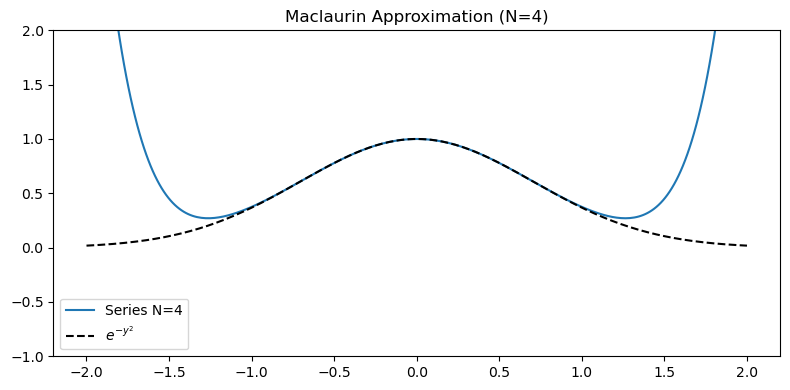

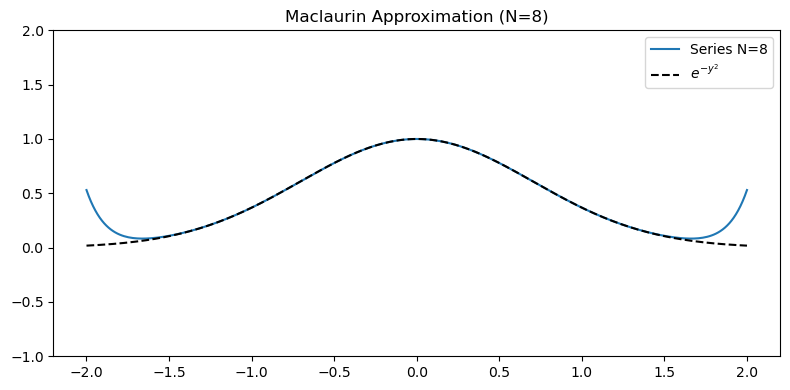

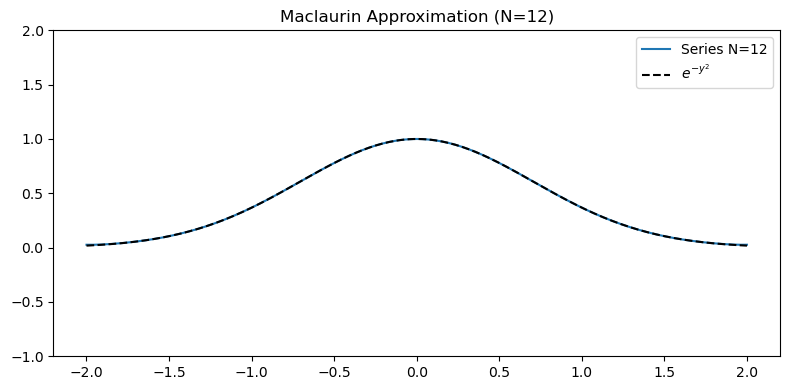

In [10]:
def prob3(N):
    x, y = sy.symbols('x y')
    # Maclaurin series for e^x up to N terms
    series = sum(x**n / sy.factorial(n) for n in range(N+1))
    # Substitute x -> -y^2
    approx = series.subs(x, -y**2)
    approx_fn = sy.lambdify(y, approx, 'numpy')

    
    y_vals = np.linspace(-2, 2, 300)
    plt.figure(figsize=(8, 4))
    plt.plot(y_vals, approx_fn(y_vals), label=f'Series N={N}')
    plt.plot(y_vals, np.exp(-y_vals**2), 'k--', label=r'$e^{-y^2}$')
    plt.ylim(-1, 2)
    plt.legend()
    plt.title(f'Maclaurin Approximation (N={N})')
    plt.tight_layout()
    plt.show()

prob3(4)
prob3(8)
prob3(12)

## Problem 4: Rose Curve

Convert the implicit rose curve equation to polar form and plot.

In [11]:
def prob4():
    r, theta = sy.symbols('r theta', positive=True)
    x_expr = r * sy.cos(theta)
    y_expr = r * sy.sin(theta)

    # Substitute into implicit equation and simplify
    numer = (x_expr**2 + y_expr**2)**sy.Rational(7,2) + \
            18*x_expr**5*y_expr - 60*x_expr**3*y_expr**3 + 18*x_expr*y_expr**5
    denom = (x_expr**2 + y_expr**2)**3
    eq = 1 - numer/denom
    eq_simplified = sy.simplify(eq)
    solutions = sy.solve(eq_simplified, r)

    # Use the real positive solution
    r_sol = [s for s in solutions if s.is_real and s > 0]
    if not r_sol:
        # Fallback: use trig identity — rose curve r = cos(6θ) or similar
        r_fn = lambda t: np.abs(np.cos(6*t))
    else:

        r_fn = sy.lambdify(theta, r_sol[0], 'numpy')

    t_vals = np.linspace(0, 2*np.pi, 2000)
    r_vals = r_fn(t_vals)
    plt.figure(figsize=(6, 6))
    plt.plot(r_vals * np.cos(t_vals), r_vals * np.sin(t_vals))
    plt.axis('equal')
    plt.title('Rose Curve')
    plt.tight_layout()
    plt.show()

prob4()

TypeError: cannot determine truth value of Relational: -78*sin(theta)**5*cos(theta) + 60*sin(theta)**3*cos(theta) - 18*sin(theta)*cos(theta)**5 + 1 > 0

## Problem 5: Eigenvalue/Eigenvector Analysis

In [12]:
def prob5():
    x, y, lam = sy.symbols('x y lambda')
    A = sy.Matrix([[x-y, x,   0  ],
                   [x,   x-y, x  ],
                   [0,   x,   x-y]])
    # Characteristic polynomial
    char_poly = (A - lam*sy.eye(3)).det()
    eigenvalues = sy.solve(char_poly, lam)

    result = {}
    for ev in eigenvalues:
        M = A - ev*sy.eye(3)
        ns = M.nullspace()
        
        result[ev] = ns

    # Verify with built-in
    print("Built-in eigenvals:", A.eigenvals())
    return result

evecs = prob5()
for val, vecs in evecs.items():
    print(f"λ = {val}: {vecs}")

Built-in eigenvals: {x - y: 1, -sqrt(2)*x + x - y: 1, x + sqrt(2)*x - y: 1}
λ = x - y: [Matrix([
[-1],
[ 0],
[ 1]])]
λ = x + sqrt(2)*x - y: [Matrix([
[      1],
[sqrt(2)],
[      1]])]
λ = -sqrt(2)*x + x - y: [Matrix([
[       1],
[-sqrt(2)],
[       1]])]


## Problem 6: Critical Point Classification

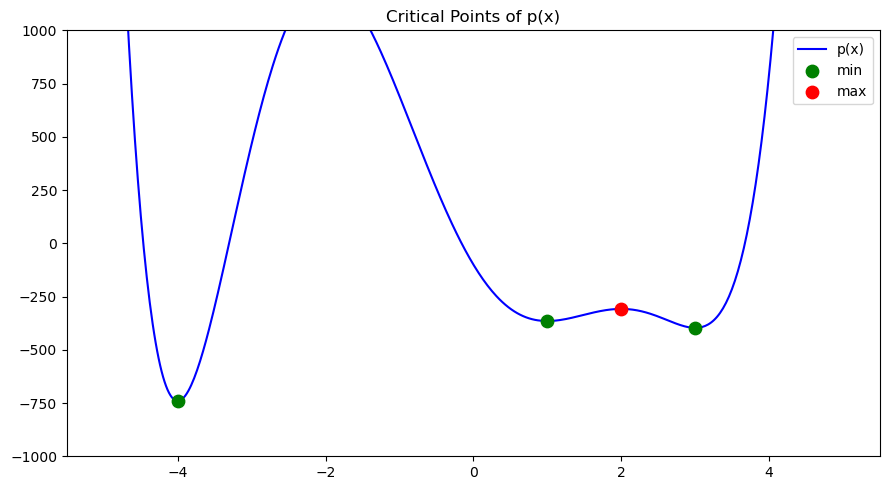

Minima: {1, 3, -4}
Maxima: {2, -2}


In [13]:
def prob6():
    x = sy.symbols('x')
    p = 2*x**6 - 51*x**4 + 48*x**3 + 312*x**2 - 576*x - 100
    dp  = sy.diff(p, x)
    d2p = sy.diff(p, x, 2)

    critical = sy.solve(dp, x)
    minima, maxima = [], []
    for cp in critical:
        val = d2p.subs(x, cp)
        if val > 0:
            minima.append(cp)
        elif val < 0:
            maxima.append(cp)

    p_fn  = sy.lambdify(x, p, 'numpy')
    x_vals = np.linspace(-5, 5, 500)
    

    plt.figure(figsize=(9, 5))
    plt.plot(x_vals, p_fn(x_vals), 'b', label='p(x)')
    for m in minima:
        mx = float(m)
        plt.scatter(mx, float(p.subs(x, m)), color='green', zorder=5, s=80, label='min')
    for m in maxima:
        mx = float(m)
        plt.scatter(mx, float(p.subs(x, m)), color='red',   zorder=5, s=80, label='max')
    plt.ylim(-1000, 1000)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.title('Critical Points of p(x)')
    plt.tight_layout()
    plt.show()

    return set(minima), set(maxima)

mins, maxs = prob6()
print("Minima:", mins)
print("Maxima:", maxs)

## Problem 7: Spherical Volume Integral

Integral: 4*pi*r**7/7
At r=3: 8748*pi/7 = 8748π/7: 8748*pi/7


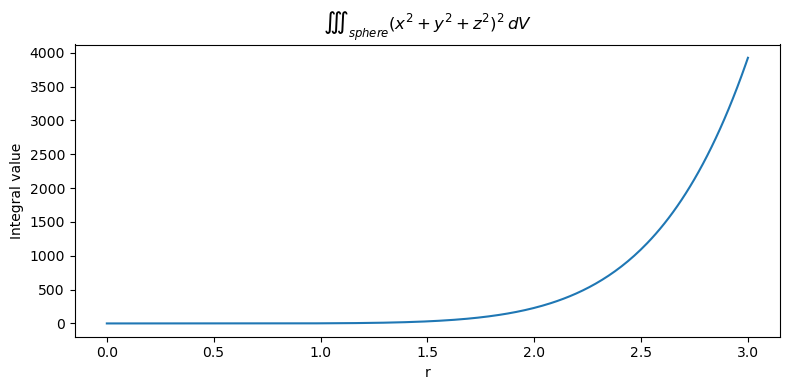

Value at r=2: 229.78506266256773


In [14]:
def prob7():
    rho, phi, theta, r = sy.symbols('rho phi theta r', positive=True)

    x_s = rho * sy.sin(phi) * sy.cos(theta)
    y_s = rho * sy.sin(phi) * sy.sin(theta)
    z_s = rho * sy.cos(phi)

    f = (x_s**2 + y_s**2 + z_s**2)**2   # = rho^4 in spherical
    jacobian = rho**2 * sy.sin(phi)
    integrand = sy.simplify(f * jacobian)  # rho^6 * sin(phi)

    integral = sy.integrate(integrand,
                            (rho, 0, r),
                            
                            (theta, 0, 2*sy.pi),
                            (phi, 0, sy.pi))
    integral = sy.simplify(integral)
    print("Integral:", integral)
    print("At r=3:", integral.subs(r, 3), "= 8748π/7:", sy.Rational(8748,7)*sy.pi)

    I_fn = sy.lambdify(r, integral, 'numpy')
    r_vals = np.linspace(0, 3, 300)
    plt.figure(figsize=(8, 4))
    plt.plot(r_vals, I_fn(r_vals))
    plt.xlabel('r')
    plt.ylabel('Integral value')
    plt.title(r'$\iiint_{sphere} (x^2+y^2+z^2)^2\,dV$')
    plt.tight_layout()
    plt.show()

    return float(integral.subs(r, 2).evalf())

print("Value at r=2:", prob7())